# Identify Longest Tracks

Top 10 Longest Tracks - Kaye Celene G. Rivera (5870)


,track_name,artist,duration_min
710,Lost Boy,Jaden,9.497883
610,I'm Getting Ready,Tasha Cobbs Leonard,8.436667
64,Mirrors,Justin Timberlake,8.069100
63,What Goes Around.../...Comes Around (Interlude),Justin Timberlake,7.476217
622,Achilles Come Down,Gang of Youths,7.035767
689,Never Let Go (Of Me),Baltra,6.909833
682,House Of Balloons / Glass Table Girls,The Weeknd,6.753550
549,Stan,Eminem,6.735100
671,Galvanize,The Chemical Brothers,6.563550
37,After Hours,The Weeknd,6.017100


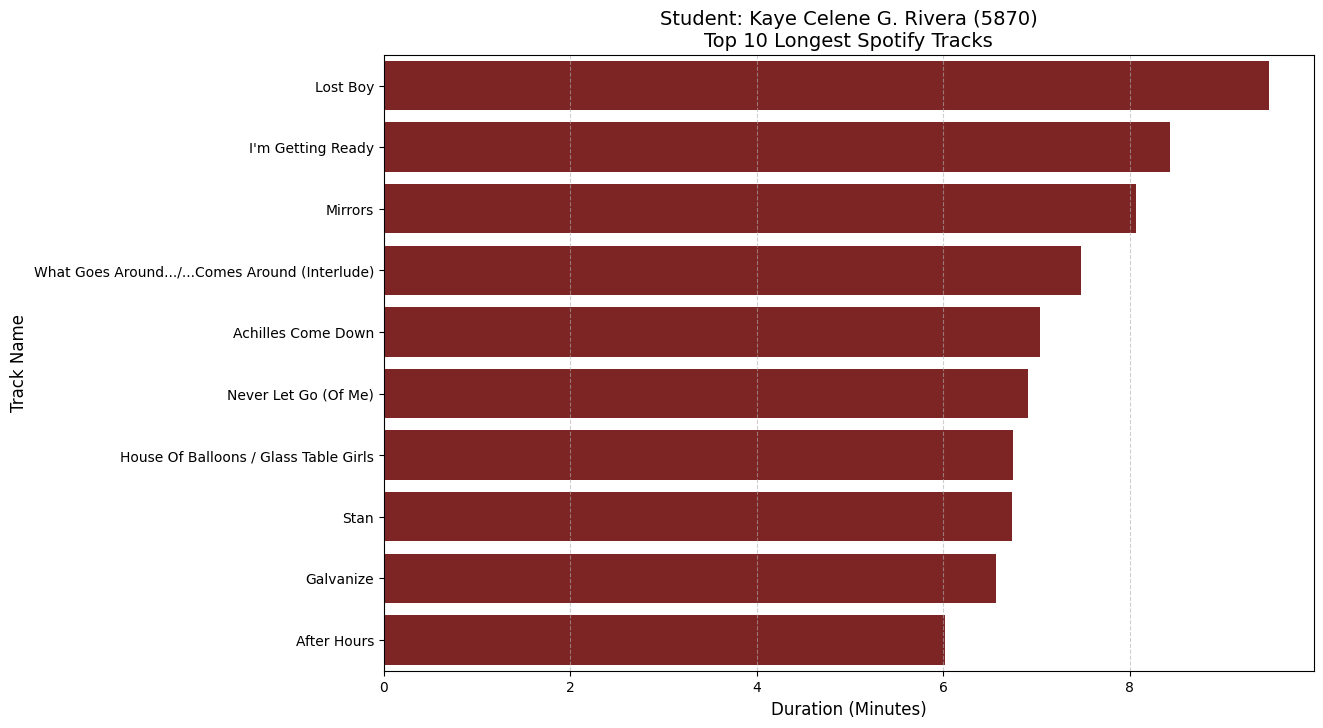

In [7]:
# 1. Setup Student Parameters
student_name = "Kaye Celene G. Rivera"
student_id = "5870"
color_bar = "#8C1515"  

# 2. Calculations: Sort and Select Top 10
# We sort by duration_min (highest first) and take the first 10
df_longest = df[['track_name', 'artist', 'duration_min']].sort_values(by='duration_min', ascending=False).head(10)

# 3. Output: Display the Table
print(f"Top 10 Longest Tracks - {student_name} ({student_id})")
display(df_longest)

# 4. Output: Personalized Horizontal Bar Chart
plt.figure(figsize=(12, 8))

sns.barplot(
    data=df_longest, 
    x='duration_min', 
    y='track_name', 
    color=color_bar  # Student-specific color
)

# Adding the student-personalized title and labels
plt.title(f"Student: {student_name} ({student_id})\nTop 10 Longest Spotify Tracks", fontsize=14)
plt.xlabel("Duration (Minutes)", fontsize=12)
plt.ylabel("Track Name", fontsize=12)

# Adding gridlines for easier reading of the bars
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

#  Song Release Trend


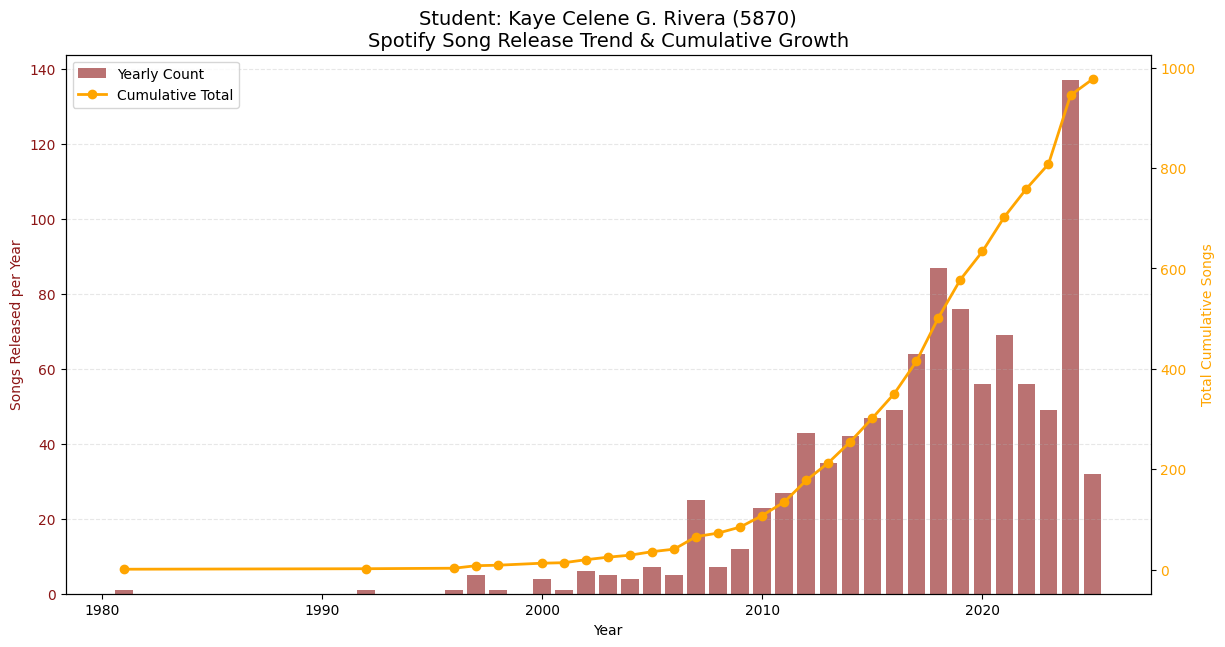

In [9]:
# 1. Setup Student Parameters
student_name = "Kaye Celene G. Rivera"
student_id = "5870"
color_bar = "#8C1515"   # Using your primary ID color
color_line = "#FFA500"  # Using your secondary ID color

# 2. Calculations: Group by year and count
yearly_counts = df.groupby('year').size().reset_index(name='song_count')

# 3. Calculation: Cumulative Growth
yearly_counts['cumulative_total'] = yearly_counts['song_count'].cumsum()

# 4. Output: Combined Bar + Line Chart
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Yearly Counts (Bars) on the first Y-axis
ax1.bar(yearly_counts['year'], yearly_counts['song_count'], color=color_bar, alpha=0.6, label='Yearly Count')
ax1.set_xlabel('Year')
ax1.set_ylabel('Songs Released per Year', color=color_bar)
ax1.tick_params(axis='y', labelcolor=color_bar)

# Create a second Y-axis for the Cumulative Total (Line)
ax2 = ax1.twinx()
ax2.plot(yearly_counts['year'], yearly_counts['cumulative_total'], color=color_line, marker='o', linewidth=2, label='Cumulative Total')
ax2.set_ylabel('Total Cumulative Songs', color=color_line)
ax2.tick_params(axis='y', labelcolor=color_line)

# Title and Layout
plt.title(f"Student: {student_name} ({student_id})\nSpotify Song Release Trend & Cumulative Growth", fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

# Animated Density Map of Duration vs Popularity

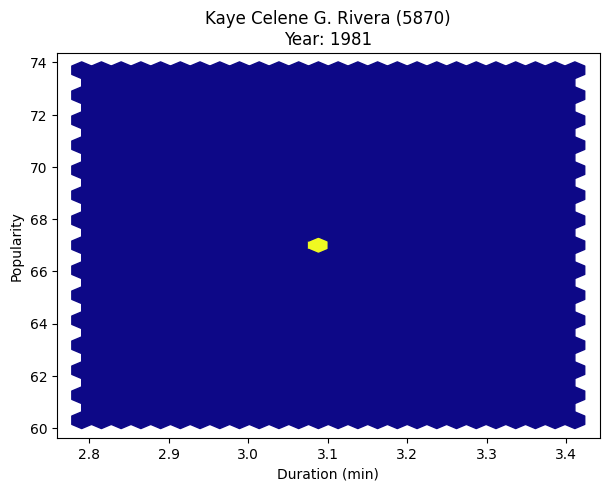

In [18]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import pandas as pd

df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['duration_min'] = pd.to_numeric(df['duration_min'], errors='coerce')
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

df_clean = df.dropna(subset=['year', 'duration_min', 'popularity']).copy()
df_clean['year'] = df_clean['year'].astype(int)

cmap_color = "plasma"

years = sorted(df_clean['year'].unique())

fig, ax = plt.subplots(figsize=(7,5))

def update(year):
    ax.clear()

    subset = df_clean[df_clean['year'] == year]

    if subset.empty:
        ax.set_title(f"{student_name} ({student_id})\nYear: {year} (No Data)")
        return

    ax.hexbin(
        subset['duration_min'],
        subset['popularity'],
        gridsize=25,
        cmap=cmap_color
    )

    ax.set_title(f"{student_name} ({student_id})\nYear: {year}")
    ax.set_xlabel("Duration (min)")
    ax.set_ylabel("Popularity")

ani = animation.FuncAnimation(fig, update, frames=years, interval=800)

HTML(ani.to_jshtml())